# TOP_K 评测可视化

- **Part 1**：三种 TO 选取策略（`best` / `mid` / `worst`）下，扫描 `top_k = 1..20`，绘制 **EM**（node_id 与 `nearest_5` 交集的 `hit_rate`）。
- **Part 2**：固定 `top_k = 1`，对比三种 TO 策略的 **EM** `hit_rate`。

#### 三种 TO 策略（来自 `rank_to.py` 排序）

| MODE | 含义 |
|------|------|
| `best` | 每个页面取 **排名第 1** 的 TO |
| `mid` | 每个页面取 **排名中位数** 的 TO |
| `worst` | 每个页面取 **排名倒数第 1** 的 TO |

对选中的 TO，用其在 `cos_sim` 矩阵中的单列与所有节点算相似度，取 top_k 个节点；**hit** = 预测 node_id 与 `nearest_5` 存在交集。

运行前请确保已生成 `Mobile3M_data/embeddings/cos_sim/*.npz`（`cal_cos_sim.py`）及 `target/TO_index/`（`llm_target.py`）。

In [1]:
import importlib.util
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["font.sans-serif"] = ["PingFang SC", "Arial Unicode MS", "Heiti SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

SEE_CNT = 50 # 查看 top k = 1 ～ 50 的命中率

# 定位 judge/ 与项目根目录
JUDGE_DIR = Path("judge")
if not (JUDGE_DIR / "judge.py").exists():
    JUDGE_DIR = JUDGE_DIR / "judge"
PROJECT_ROOT = JUDGE_DIR.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


def _load_module(name: str, path: Path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    spec.loader.exec_module(mod)
    return mod


judge_mod = _load_module("judge_mod", JUDGE_DIR / "judge.py")
rank_to_mod = _load_module("rank_to_mod", JUDGE_DIR / "rank_to.py")

MODES = ["best", "mid", "worst"]
MODE_LABELS = {"best": "TO=best", "mid": "TO=mid", "worst": "TO=worst"}
MODE_COLORS = {"best": "#55A868", "mid": "#4C72B0", "worst": "#C44E52"}


def _sort_by_mode(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["mode"] = pd.Categorical(out["mode"], categories=MODES, ordered=True)
    return out.sort_values("mode").reset_index(drop=True)

from config.data_paths import BASE_DIR

cos_sim_dir = BASE_DIR / "embeddings" / "cos_sim"
stems = sorted(p.stem for p in cos_sim_dir.glob("*.npz"))
print(f"项目根目录: {PROJECT_ROOT}")
print(f"BASE_DIR: {BASE_DIR.name}")
print(f"cos_sim 样本数: {len(stems)}")
if stems:
    print(f"  示例: {stems[0]} ... {stems[-1]}")

项目根目录: .
BASE_DIR: Mobile3M_data
cos_sim 样本数: 529
  示例: QQmusic0_10_195_000 ... QQmusic0_9_221_000


## Part 1 — 三种 TO 策略：不同 top_k 的 EM

In [2]:
import json

import numpy as np

STEP_GT_DIR = BASE_DIR / "step_GT"


def pick_to_id(ranking: list[dict], mode: str) -> int:
    """从 rank_to 排行榜中选取 best / mid / worst 的 TO_id。"""
    n = len(ranking)
    if n == 0:
        raise ValueError("ranking is empty")
    if mode == "best":
        return int(ranking[0]["TO_id"])
    if mode == "worst":
        return int(ranking[-1]["TO_id"])
    if mode == "mid":
        return int(ranking[(n - 1) // 2]["TO_id"])
    raise ValueError(f"unknown mode: {mode!r}")


def judge_hit_with_to(stem: str, top_k: int, to_id: int) -> dict:
    """用单个 TO 的相似度列做 top_k 检索，判定 hit@k。"""
    cos_sim_path = cos_sim_dir / f"{stem}.npz"
    gt_path = STEP_GT_DIR / f"{stem}.json"

    with np.load(cos_sim_path) as data:
        sim_matrix = data["sim_matrix"]
        node_ids = data["node_ids"]
        to_ids = data["to_ids"]

    col_idx = int(np.where(to_ids == to_id)[0][0])
    final_sims = sim_matrix[:, col_idx]
    pred_node_ids, pred_scores = judge_mod._rank_top_k(final_sims, node_ids, top_k)

    with open(gt_path, "r", encoding="utf-8") as f:
        gt_data = json.load(f)
    from utils.gt_node_match import gt_node_ids_from_step_gt

    gt_node_ids = gt_node_ids_from_step_gt(gt_data)
    matched = sorted(set(pred_node_ids) & set(gt_node_ids))

    return {
        "stem": stem,
        "hit": len(matched) > 0,
        "top_k": top_k,
        "to_id": to_id,
        "pred_node_ids": pred_node_ids,
        "pred_scores": pred_scores,
        "gt_node_ids": gt_node_ids,
        "matched_node_ids": matched,
    }


print("预计算 TO 排名...")
rank_cache: dict[str, list[dict]] = {}
rank_errors: list[str] = []
for stem in stems:
    try:
        rank_cache[stem] = rank_to_mod.rank_to_for_stem(stem)["ranking"]
    except (FileNotFoundError, ValueError) as exc:
        rank_errors.append(f"{stem}: {exc}")
print(f"  成功: {len(rank_cache)}, 跳过: {len(rank_errors)}")

TOP_K_LIST = list(range(1, SEE_CNT + 1))

judge_rows = []
for mode in MODES:
    for top_k in TOP_K_LIST:
        hits = 0
        errors = list(rank_errors)
        for stem, ranking in rank_cache.items():
            try:
                to_id = pick_to_id(ranking, mode)
                result = judge_hit_with_to(stem, top_k, to_id)
                hits += int(result["hit"])
            except (FileNotFoundError, ValueError, IndexError) as exc:
                errors.append(f"{stem}: {exc}")
        total = len(rank_cache)
        judge_rows.append({
            "mode": mode,
            "top_k": top_k,
            "total": total,
            "hit_count": hits,
            "hit_rate": round(hits / total, 4) if total > 0 else 0.0,
            "errors": len(errors),
        })

df_judge = pd.DataFrame(judge_rows)
pivot_judge = (
    df_judge.pivot(index="mode", columns="top_k", values="hit_rate")
    .reindex(index=MODES)
    .round(4)
)
display(pivot_judge)

预计算 TO 排名...
  成功: 529, 跳过: 0


top_k,1,2,3,4,5,6,7,8,9,10,...,41,42,43,44,45,46,47,48,49,50
mode,,,,,,,,,,,,,,,,,,,,,
best,0.7732,0.7902,0.8110,0.8223,0.8355,0.8526,0.8582,0.8582,0.8620,0.8620,...,0.9376,0.9395,0.9395,0.9395,0.9414,0.9452,0.9452,0.9452,0.9452,0.9452
mid,0.3195,0.4575,0.5104,0.6200,0.6427,0.6616,0.6824,0.6957,0.7127,0.7221,...,0.9017,0.9036,0.9093,0.9130,0.9149,0.9168,0.9187,0.9206,0.9225,0.9263
worst,0.1096,0.1758,0.2042,0.2174,0.2363,0.2476,0.2911,0.3289,0.4045,0.4726,...,0.8318,0.8469,0.8601,0.8696,0.8715,0.8790,0.8809,0.8885,0.8904,0.8904


/var/folders/4x/vk43ls6s5xdbcnk23qh1bp_00000gn/T/ipykernel_19501/600988384.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(value)


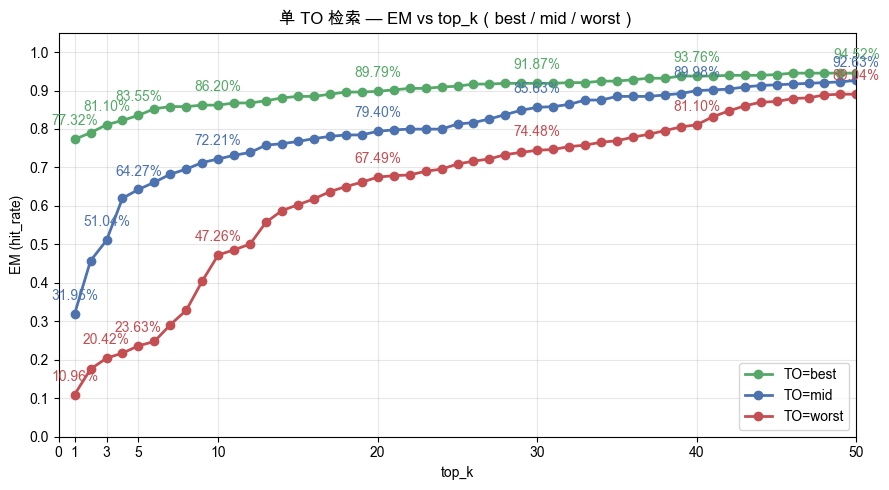

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

for mode in MODES:
    sub = df_judge[df_judge["mode"] == mode].sort_values("top_k")
    ax.plot(
        sub["top_k"],
        sub["hit_rate"],
        marker="o",
        linewidth=2,
        label=MODE_LABELS[mode],
        color=MODE_COLORS[mode],
    )
    # 标注数据点
    for k in [0, 1, 3, 5, 10, 20, 30, 40, 50]:
        value = sub[sub["top_k"] == k]["hit_rate"]
        if not value.empty:
            x = k
            y = float(value)
            ax.annotate(
                f"{y:.2%}",
                (x, y),
                textcoords="offset points",
                xytext=(0, 10),
                ha='center',
                fontsize=10,
                color=MODE_COLORS[mode]
            )

ax.set_xlabel("top_k")
ax.set_ylabel("EM (hit_rate)")
ax.set_title("单 TO 检索 — EM vs top_k（best / mid / worst）")

# 横轴只标注部分关键点，且确保0也显示出来
xticks_major = [0, 1, 3, 5, 10, 20, 30, 40, 50]
ax.set_xticks(xticks_major)
ax.set_xlim(0, max(TOP_K_LIST))  # 横轴从0开始确保显示0

# 纵轴精确到0.1
yticks_major = [round(x * 0.1, 1) for x in range(0, 11)]
ax.set_yticks(yticks_major)
ax.set_ylim(0, 1.05)

ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Part 2 — 三种 TO 策略：top_k = 1 的 hit_rate 对比

In [4]:
df_top1 = _sort_by_mode(df_judge[df_judge["top_k"] == 1][["mode", "total", "hit_count", "hit_rate", "errors"]])
display(df_top1)

,mode,total,hit_count,hit_rate,errors
0,best,529,409,0.7732,0
1,mid,529,169,0.3195,0
2,worst,529,58,0.1096,0


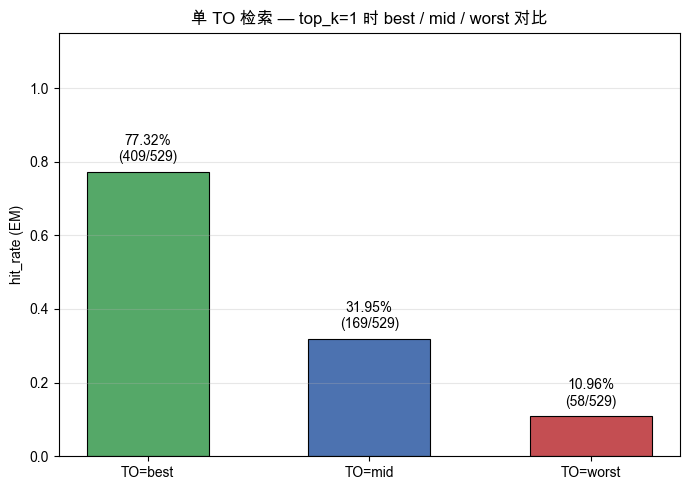

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    [MODE_LABELS[m] for m in df_top1["mode"]],
    df_top1["hit_rate"],
    color=[MODE_COLORS[m] for m in df_top1["mode"]],
    width=0.55,
    edgecolor="black",
    linewidth=0.8,
)

for bar, rate, cnt, total in zip(bars, df_top1["hit_rate"], df_top1["hit_count"], df_top1["total"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{rate:.2%}\n({cnt}/{total})",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_ylabel("hit_rate (EM)")
ax.set_title("单 TO 检索 — top_k=1 时 best / mid / worst 对比")
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# 汇总：top_k=1 时三种 TO 策略的 hit_rate
compare = _sort_by_mode(df_top1[["mode", "hit_count", "total", "hit_rate"]].rename(columns={"hit_rate": "hit@1"}))
display(compare)
print("best >= mid >= worst（预期排序，best 为 rank_to 排名第 1 的 TO）")

,mode,hit_count,total,hit@1
0,best,409,529,0.7732
1,mid,169,529,0.3195
2,worst,58,529,0.1096


best >= mid >= worst（预期排序，best 为 rank_to 排名第 1 的 TO）
